In [1]:
import sys
import os
import datetime
from dateutil.relativedelta import relativedelta

import pandas as pd
import numpy as np

# import yfinance as yf
# from fredapi import Fred

import matplotlib.pyplot as plt

In [2]:
import src.dislocation_analysis as DA

In [3]:
plot_ratio = pd.read_csv(os.path.join(os.environ['PYTHONPATH'],'data','OVX_VIX_Ratio.csv'),index_col=0)
plot_ratio = plot_ratio.set_index('Date')
plot_ratio.index = pd.to_datetime(plot_ratio.index)

plot_ratio = plot_ratio.loc[~plot_ratio['Z_Score'].isna(),:]
plot_ratio.index = plot_ratio.index.map(lambda x: pd.to_datetime(x).date())
plot_ratio.head()

,OVX,VIX,Ratio,Rolling30,Diff,Mean,STD,Z_Score,Max_1y_Z_Score,Min_1y_Z_Score
Date,,,,,,,,,,
2008-05-09,37.430000,19.410000,1.928387,1.881357,0.047030,1.558837,0.278349,1.327652,NaN,NaN
2008-05-12,37.549999,17.790001,2.110736,1.900537,0.210199,1.557401,0.278086,1.989799,NaN,NaN
2008-05-13,38.110001,17.980000,2.119577,1.912812,0.206765,1.559623,0.279768,2.001492,NaN,NaN
2008-05-14,36.799999,17.660000,2.083805,1.925422,0.158383,1.561687,0.281140,1.857147,NaN,NaN
2008-05-15,38.770000,16.299999,2.378528,1.946154,0.432374,1.563372,0.284725,2.862958,NaN,NaN


In [4]:
spx_index = DA.extract_hist_yf("^SPX")
spx_index.index = map(lambda x: pd.to_datetime(x).date(),spx_index.index)
spx_index = spx_index.loc[:,['Open','High','Low','Close']]
spx_index = spx_index.rename(columns={'Close':'SPX'})

Long_Name='S&P 500 INDEX'
Symbol='^SPX'
                                  Open         High          Low        Close
Date                                                                         
2025-08-06 00:00:00-04:00  6309.299805  6352.830078  6301.109863  6345.060059
2025-08-07 00:00:00-04:00  6374.319824  6389.709961  6310.319824  6340.000000
2025-08-08 00:00:00-04:00  6355.220215  6388.950195  6355.220215  6385.700195
Removing today's value as market is still open (now: 2025-08-08 11:28:10.891383)


Time Series data from 1927-12-30 to 2025-08-07. Total of 24516 observation


In [5]:
uso_index = DA.extract_hist_yf("USO")
uso_index.index = map(lambda x: pd.to_datetime(x).date(),uso_index.index)
uso_index = uso_index.loc[:,['Open','High','Low','Close']]

uso_index = uso_index.rename(columns={'Close':'USO'})

Long_Name='United States Oil Fund, LP'
Symbol='USO'
                                Open       High        Low      Close
Date                                                                 
2025-08-06 00:00:00-04:00  76.309998  76.839996  73.320000  73.790001
2025-08-07 00:00:00-04:00  74.059998  74.540001  73.419998  73.419998
2025-08-08 00:00:00-04:00  73.930000  74.400002  72.400002  73.949997
Removing today's value as market is still open (now: 2025-08-08 11:28:11.696782)


Time Series data from 2006-04-10 to 2025-08-07. Total of 4863 observation


,OVX,VIX,Z_Score,SPX,USO
Date,,,,,
2008-05-09,37.430000,19.410000,1.327652,1388.280029,816.960022
2008-05-12,37.549999,17.790001,1.989799,1403.579956,800.880005
2008-05-13,38.110001,17.980000,2.001492,1403.040039,813.679993
2008-05-14,36.799999,17.660000,1.857147,1408.660034,801.760010
2008-05-15,38.770000,16.299999,2.862958,1423.569946,801.679993


In [96]:
df = plot_ratio.loc[:,['OVX','VIX','Z_Score']]
df = pd.merge(df,spx_index.loc[:,['SPX']],how='left',left_index=True,right_index=True)
df = pd.merge(df,uso_index.loc[:,['USO']],how='left',left_index=True,right_index=True)
N = df.shape[0]

df.loc[:,'SPX_30D'] = np.nan
df.loc[:,'USO_30D'] = np.nan

df.iloc[:-30,-2] = df.iloc[30:,:]['SPX'].values
df.iloc[:-30,-1] = df.iloc[30:,:]['USO'].values

df.loc[:,'SPX_Change'] = (df['SPX_30D']-df['SPX'])
df.loc[:,'USO_Change'] = (df['USO_30D']-df['USO'])

df.loc[:,'SPX_Change_PCT'] = (df['SPX_30D']-df['SPX'])/df['SPX']
df.loc[:,'USO_Change_PCT'] = (df['USO_30D']-df['USO'])/df['USO']

df.loc[:,'Max_Ratio']=np.nan
df.loc[:,'Min_Ratio']=np.nan
    
for i in range(N-30):
    st_index = df.index[i]
    next_index = df.index[i+1]
    end_index = df.index[i+30]
    time_series_subset = df.loc[next_index:end_index,:]
    # calculate the max and min ratio
    ratio = time_series_subset['USO_Change_PCT']/time_series_subset['SPX_Change_PCT']
    ratio = ratio.dropna()
    if len(ratio)==30:
        df.loc[st_index,'Max_Ratio'] = max(ratio)
        df.loc[st_index,'Min_Ratio'] = min(ratio)



In [98]:
df.head(3)

,OVX,VIX,Z_Score,SPX,USO,SPX_30D,USO_30D,SPX_Change,USO_Change,SPX_Change_PCT,USO_Change_PCT,Max_Ratio,Min_Ratio
Date,,,,,,,,,,,,,
2008-05-09,37.430000,19.410000,1.327652,1388.280029,816.960022,1318.000000,887.359985,-70.280029,70.399963,-0.050624,0.086173,5.499934,-1.702105
2008-05-12,37.549999,17.790001,1.989799,1403.579956,800.880005,1314.290039,887.599976,-89.289917,86.719971,-0.063616,0.108281,7.329257,-1.444652
2008-05-13,38.110001,17.980000,2.001492,1403.040039,813.679993,1321.969971,868.000000,-81.070068,54.320007,-0.057782,0.066758,7.329257,-1.444652


In [108]:
df.tail(66).head(10)

,OVX,VIX,Z_Score,SPX,USO,SPX_30D,USO_30D,SPX_Change,USO_Change,SPX_Change_PCT,USO_Change_PCT,Max_Ratio,Min_Ratio
Date,,,,,,,,,,,,,
2025-03-21,28.430000,19.280001,-1.696157,5667.560059,73.790001,5650.379883,62.369999,-17.180176,-11.420002,-0.003031,-0.154764,20.031408,-3.010333
2025-03-24,29.670000,17.480000,-0.987857,5767.569824,74.879997,5606.910156,64.599998,-160.659668,-10.279999,-0.027856,-0.137286,20.031408,-3.010333
2025-03-25,28.270000,17.150000,-1.135630,5776.649902,74.820000,5631.279785,63.509998,-145.370117,-11.310001,-0.025165,-0.151163,20.031408,-3.010333
2025-03-26,28.840000,18.330000,-1.358581,5712.200195,75.419998,5663.939941,65.599998,-48.260254,-9.820000,-0.008449,-0.130204,20.031408,-3.010333
2025-03-27,28.490000,18.690001,-1.497767,5693.310059,75.480003,5659.910156,66.610001,-33.399902,-8.870003,-0.005867,-0.117515,5.432832,-3.010333
2025-03-28,28.700001,21.650000,-2.085645,5580.939941,74.769997,5844.189941,67.599998,263.250000,-7.169998,0.047169,-0.095894,5.432832,-3.010333
2025-03-31,30.879999,22.280001,-1.879067,5611.850098,77.330002,5886.549805,69.589996,274.699707,-7.740005,0.048950,-0.100091,NaN,NaN
2025-04-01,30.570000,21.770000,-1.807919,5633.069824,77.080002,5892.580078,68.730003,259.510254,-8.349998,0.046069,-0.108329,NaN,NaN
2025-04-02,29.980000,21.510000,-1.819856,5670.970215,77.739998,5916.930176,67.589996,245.959961,-10.150002,0.043372,-0.130563,NaN,NaN


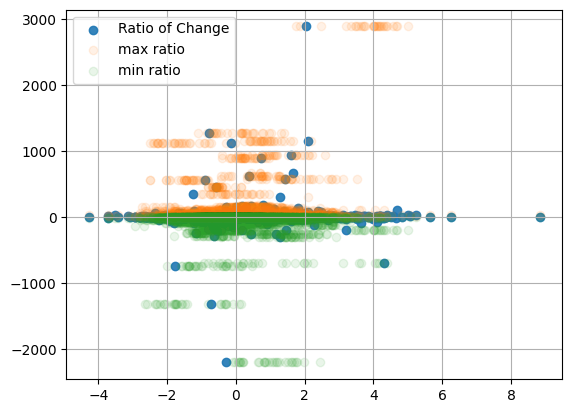

In [114]:
plt.figure()
plt.grid()
# plt.scatter(df['Z_Score'],df['SPX_Change_PCT'],label='SPX_Change',alpha=0.2)
# plt.scatter(df['Z_Score'],df['USO_Change_PCT'],label='USO_Change',alpha=0.2)

plt.scatter(df['Z_Score'],df['USO_Change_PCT']/df['SPX_Change_PCT'],label='Ratio of Change',alpha=0.9)


plt.scatter(df['Z_Score'],df['Max_Ratio'],label='max ratio',alpha=0.1)
plt.scatter(df['Z_Score'],df['Min_Ratio'],label='min ratio',alpha=0.1)

# plt.ylim([-10,10])

plt.legend()

plt.show()